<a href="https://colab.research.google.com/github/nabihaimtiaz267-blip/OIBSIP/blob/main/Emotion%20Recognition%20from%20Speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Step 1: Import basic libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Step 2: Create a dummy dataset
# Instead of extracting MFCCs, we simulate features with random numbers
# Each row = one audio sample, each column = one "feature"
data = np.random.rand(100, 20)   # 100 samples, 20 features
labels = np.random.choice(["happy", "sad", "angry"], 100)

# Step 3: Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=42)

# Step 5: Train a simple classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))



Classification Report:

              precision    recall  f1-score   support

       angry       0.20      0.33      0.25         3
       happy       0.62      0.38      0.48        13
         sad       0.29      0.50      0.36         4

    accuracy                           0.40        20
   macro avg       0.37      0.41      0.36        20
weighted avg       0.49      0.40      0.42        20



Cross-validation accuracy scores: [0.3   0.475 0.325 0.35  0.45 ]
Mean CV accuracy: 0.37999999999999995

Classification Report:

              precision    recall  f1-score   support

       angry       0.33      0.24      0.28        17
       happy       0.64      0.70      0.67        20
         sad       0.44      0.54      0.48        13

    accuracy                           0.50        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.48      0.50      0.49        50



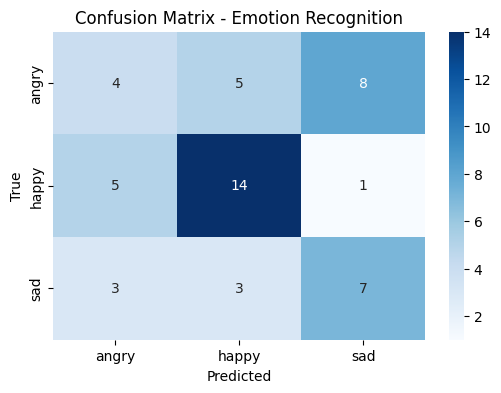

In [4]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 2: Create a dummy dataset (simulate MFCC-like features)
data = np.random.rand(200, 20)   # 200 samples, 20 features
labels = np.random.choice(["happy", "sad", "angry"], 200)

# Step 3: Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.25, random_state=42)

# Step 5: Train classifier with cross-validation
model = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(model, data, y, cv=5, scoring="accuracy")
print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Fit final model
model.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Step 7: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Emotion Recognition")
plt.show()
